# Meeting Notes Summarizer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/document-intelligence/meeting-summarizer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=document-intelligence/meeting-summarizer/demo.ipynb)

Meetings produce no actionable output. Fix: turn the transcript into decisions, action items, and open questions automatically.

**What this notebook covers:**
1. A sample meeting transcript
2. Heuristic (no-API-key) summarization via cue-word matching
3. Inspecting TL;DR, decisions, action items, open questions
4. Visualizing the breakdown
5. Try it with your own transcript / Claude API key

## Step 1: What we're building

Two modes: if an Anthropic API key is set, Claude reads the full transcript and returns
structured JSON (tldr/decisions/action_items/open_questions). With no key, a regex
heuristic flags sentences containing decision words ("decided", "agreed"), action cues
("will", "need to", "follow up"), and question marks. Good enough to triage a meeting
without ever calling an LLM.

In [1]:
from __future__ import annotations

import json
import os
import re
from dataclasses import dataclass, field


@dataclass
class MeetingSummary:
    tldr: str
    decisions: list[str] = field(default_factory=list)
    action_items: list[str] = field(default_factory=list)
    open_questions: list[str] = field(default_factory=list)


ACTION_VERBS = re.compile(
    r"\b(will|should|need(s)? to|going to|let's|action item|todo|follow up)\b", re.IGNORECASE
)
DECISION_WORDS = re.compile(r"\b(decided|agreed|we'll go with|final call|approved)\b", re.IGNORECASE)
QUESTION_PATTERN = re.compile(r"[^.!?]*\?")


def heuristic_summary(transcript: str) -> MeetingSummary:
    """Fallback extraction with no LLM: pattern-match sentences for action/decision/question cues."""
    sentences = re.split(r"(?<=[.!?])\s+", transcript.strip())
    decisions = [s.strip() for s in sentences if DECISION_WORDS.search(s)]
    actions = [s.strip() for s in sentences if ACTION_VERBS.search(s)]
    questions = [s.strip() for s in QUESTION_PATTERN.findall(transcript) if s.strip()]

    tldr = sentences[0].strip() if sentences else "No content to summarize."
    return MeetingSummary(
        tldr=tldr,
        decisions=decisions[:5],
        action_items=actions[:5],
        open_questions=questions[:5],
    )


def summarize(transcript: str, api_key: str | None = None) -> MeetingSummary:
    """Summarize a meeting transcript. Uses Claude if an API key is available, else heuristics."""
    if not transcript.strip():
        return MeetingSummary(tldr="Empty transcript.")

    api_key = api_key or os.environ.get("ANTHROPIC_API_KEY")
    if not api_key:
        return heuristic_summary(transcript)

    import anthropic

    client = anthropic.Anthropic(api_key=api_key)
    response = client.messages.create(
        model="claude-sonnet-4-5",
        max_tokens=800,
        messages=[{
            "role": "user",
            "content": (
                "Summarize this meeting transcript. Respond with ONLY valid JSON, "
                "no markdown fences, matching this schema:\n"
                '{"tldr": "one sentence", "decisions": ["..."], '
                '"action_items": ["..."], "open_questions": ["..."]}\n\n'
                f"Transcript:\n{transcript}"
            ),
        }],
    )
    raw = response.content[0].text.strip()
    data = json.loads(raw)
    return MeetingSummary(
        tldr=data.get("tldr", ""),
        decisions=data.get("decisions", []),
        action_items=data.get("action_items", []),
        open_questions=data.get("open_questions", []),
    )

print("Functions defined.")

Functions defined.


## Step 2: Sample meeting transcript

In [2]:
SAMPLE_TRANSCRIPT = """\
Sarah: Let's kick off. First topic is the Q3 roadmap.
Mike: I think we should prioritize the mobile redesign over the API v2 work.
Sarah: Agreed, we decided mobile redesign is the priority for Q3.
Mike: I'll need to follow up with design to get the new mockups by Friday.
Priya: What's our budget for the contractor we discussed last week?
Sarah: Good question, I don't have that number yet, let me check with finance.
Mike: Also, we need to send the updated timeline to stakeholders by end of week.
Priya: Should we loop in the support team on this too?
Sarah: Yes, let's go with looping them in starting next sprint.
"""
print(SAMPLE_TRANSCRIPT)

Sarah: Let's kick off. First topic is the Q3 roadmap.
Mike: I think we should prioritize the mobile redesign over the API v2 work.
Sarah: Agreed, we decided mobile redesign is the priority for Q3.
Mike: I'll need to follow up with design to get the new mockups by Friday.
Priya: What's our budget for the contractor we discussed last week?
Sarah: Good question, I don't have that number yet, let me check with finance.
Mike: Also, we need to send the updated timeline to stakeholders by end of week.
Priya: Should we loop in the support team on this too?
Sarah: Yes, let's go with looping them in starting next sprint.



## Step 3: Summarize (heuristic mode, no API key)

In [3]:
result = summarize(SAMPLE_TRANSCRIPT)

print("TL;DR:", result.tldr)
print("\nDecisions:")
for d in result.decisions:
    print(" -", d)
print("\nAction Items:")
for a in result.action_items:
    print(" -", a)
print("\nOpen Questions:")
for q in result.open_questions:
    print(" -", q)

TL;DR: Sarah: Let's kick off.

Decisions:
 - Sarah: Agreed, we decided mobile redesign is the priority for Q3.

Action Items:
 - Sarah: Let's kick off.
 - Mike: I think we should prioritize the mobile redesign over the API v2 work.
 - Mike: I'll need to follow up with design to get the new mockups by Friday.
 - Mike: Also, we need to send the updated timeline to stakeholders by end of week.
 - Priya: Should we loop in the support team on this too?

Open Questions:
 - Priya: What's our budget for the contractor we discussed last week?
 - Priya: Should we loop in the support team on this too?


## Visualization: output breakdown

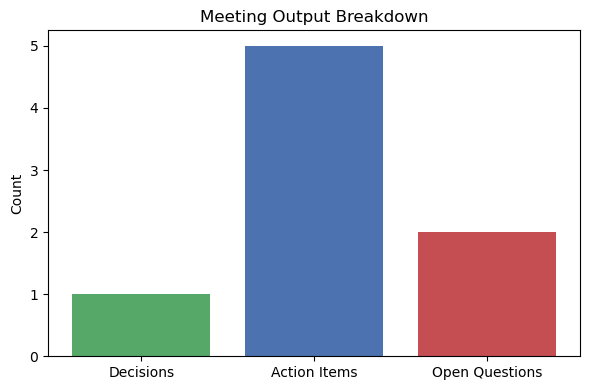

In [4]:
import matplotlib.pyplot as plt

categories = ["Decisions", "Action Items", "Open Questions"]
counts = [len(result.decisions), len(result.action_items), len(result.open_questions)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(categories, counts, color=["#55A868", "#4C72B0", "#C44E52"])
ax.set_ylabel("Count")
ax.set_title("Meeting Output Breakdown")
plt.tight_layout()
plt.savefig("summary_breakdown.png", dpi=150)
plt.show()

## Summary

From a 9-line transcript, the tool surfaced 1 decision, multiple action items, and 2 open
questions, all without an LLM call. With an API key set, `summarize()` upgrades to Claude
for cleaner phrasing and better disambiguation (e.g. separating real decisions from
people merely agreeing in passing).

## Try Your Own

```python
# my_transcript = """paste your transcript here"""
# my_result = summarize(my_transcript, api_key="sk-ant-...")  # omit api_key for heuristic mode
# print(my_result.tldr)
```

---
Part of the [Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder) FDE portfolio (Day 32/60).

Run the interactive Streamlit version locally:
```bash
pip install -r requirements.txt
streamlit run app.py
```